In [56]:
import os
import time
from datetime import datetime
import src.phasebalance.phase_unbalance_utils as m
from typing import Optional, Tuple
import pandas as pd
import numpy as np
import src.phasebalance.janitza_report_device as jrd

try:
    import matplotlib.pyplot as plt
    from matplotlib.patches import Circle
except Exception:  # matplotlib not available
    plt = None
    Circle = None

FREQ = pd.Timedelta(minutes=15)

def parse_dnr(d): 
    """
    'D0411' -> 411
    'D1354' -> 1354
    """
    s = str(d).strip()
    if not s or not s.startswith("D"):
        return None
    digits = s[1:].lstrip("0")  # remove 'D' and leading zeros
    if digits == "":
        return None
    return int(digits)

def make_expected_grid(df, freq=FREQ):
    """Build full expected 15-min grid per (substation, transformer) over its observed span."""
    out = []
    for (sid, tr), g in df.groupby(["substation_id", "transformer"]):
        t0 = g["ts"].min()
        t1 = g["ts"].max()
        grid = pd.date_range(t0, t1, freq=freq)
        out.append(pd.DataFrame({"substation_id": sid, "transformer": tr, "ts": grid}))
    return pd.concat(out, ignore_index=True)

def _severity_donut_for_metric(
    df: pd.DataFrame,
    metric: str,
    threshold: float,      # kept for API-compatibility; intentionally unused
    outdir: str,           # kept for API-compatibility; intentionally unused
    per_device: bool = True,
    agg: str = "median",
    labels: Tuple[str, str, str] = ("Low", "Medium", "High"),
    *,
    low: float = 0.15,
    mid: float = 0.30,
    high: float = 0.50,
):
    """
    Doughnut chart showing severity breakdown for `metric`.

    Bins (custom edges):
      Low    : value < low
      Medium : low <= value < mid
      High   : value >= mid   (includes values >= high too, since only 3 classes)

    Notes:
    - `threshold` and `outdir` are accepted to keep the same call signature as before,
      but are not used.
    - If you want `high` to be a *hard cap* (i.e., separate "Very High"), you’d need
      a 4th label/category.
    """
    if plt is None or Circle is None:
        print("matplotlib not available; skipping severity doughnut.")
        return None
    if metric not in df.columns:
        print(f"[{metric}] not found; skipping severity doughnut.")
        return None

    # sanity check for thresholds
    low = float(low)
    mid = float(mid)
    high = float(high)
    if not (low < mid < high):
        raise ValueError(f"Expected low < mid < high, got low={low}, mid={mid}, high={high}")

    # choose the series to bin
    ser = pd.to_numeric(df[metric], errors="coerce").dropna()
    if ser.empty:
        print(f"[{metric}] no numeric values; skipping severity doughnut.")
        return None

    if per_device and "device_id" in df.columns:
        g = df.dropna(subset=[metric]).copy()
        g[metric] = pd.to_numeric(g[metric], errors="coerce")

        agg_map = {"median": "median", "mean": "mean", "max": "max", "min": "min"}
        if agg not in agg_map:
            raise ValueError(f"Unsupported agg='{agg}'")

        ser = getattr(g.groupby("device_id")[metric], agg_map[agg])().dropna()

    if ser.empty:
        print(f"[{metric}] aggregation produced no data; skipping.")
        return None

    # define bins:
    # Low: (-inf, low)
    # Medium: [low, mid)
    # High: [mid, +inf)  (so high is not a new category, just a reference)
    bins = [float("-inf"), low, mid, float("inf")]
    cats = pd.cut(
        ser.astype(float).to_numpy(),
        bins=bins,
        labels=list(labels),
        right=False,
        include_lowest=True,
    )

    counts = pd.Series(cats).value_counts().reindex(list(labels), fill_value=0)
    if int(counts.sum()) == 0:
        print(f"[{metric}] no counts in any bin; skipping.")
        return None

    counts_np = counts.astype(int).to_numpy()

    def _autopct(pct: float) -> str:
        return f"{pct:.1f}%" if pct >= 3 else ""

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.pie(
        counts_np,
        labels=[f"{lab} ({n})" for lab, n in zip(counts.index, counts_np)],
        autopct=_autopct,
        startangle=90,
    )

    centre_circle = Circle((0, 0), 0.60, fc="white")
    ax.add_artist(centre_circle)
    ax.axis("equal")
    ax.set_title(
        f"{metric}: severity breakdown "
        f"({'per device ' + agg if per_device else 'all rows'}) "
        f"[low<{low}, mid<{mid}, high≥{high}]"
    )

    fig.tight_layout()
    return fig


def barplot_by_device(
    df: pd.DataFrame,
    metric: str,
    outdir: str,                 # kept for API-compatibility; intentionally unused
    top_n: int | None = None,
):
    """
    Create a bar chart of `metric` vs device_id.

    Works if device_id is:
      - a column (device_id / deviceId / Device_ID / etc.), OR
      - the index (index.name == 'device_id'), OR
      - a MultiIndex level named 'device_id'.

    Returns a matplotlib Figure (not saved, not closed). None if skipped.
    """
    if plt is None:
        print("matplotlib not available; skipping plots.")
        return None

    if metric not in df.columns:
        print(f"[{metric}] metric column missing; skipping.")
        return None

    # ---- Find device ids (column OR index) ----
    candidates = ("device_id", "deviceId", "deviceID", "Device_ID", "DeviceId")

    # 1) Try columns (robust to whitespace)
    cols = {str(c).strip(): c for c in df.columns}  # stripped -> original
    device_col = next((cols[c] for c in candidates if c in cols), None)

    if device_col is not None:
        device_ids = df[device_col]
    else:
        # 2) Try index
        idx = df.index
        if isinstance(idx, pd.MultiIndex):
            if "device_id" in idx.names:
                device_ids = idx.get_level_values("device_id")
            else:
                print(f"[{metric}] device_id not found in columns or MultiIndex levels; skipping.")
                return None
        else:
            if idx.name in candidates:
                device_ids = idx
            else:
                print(f"[{metric}] device_id not found in columns or index name; skipping.")
                return None

    sub = pd.DataFrame(
        {
            "device_id": device_ids.astype(str).to_numpy(),
            metric: pd.to_numeric(df[metric], errors="coerce").to_numpy(),
        }
    ).dropna(subset=[metric])

    # sort by metric desc (stable sort)
    sub = sub.sort_values(metric, ascending=False, kind="mergesort")

    if top_n is not None:
        sub = sub.head(top_n)

    n = len(sub)
    if n == 0:
        print(f"[{metric}] No valid data to plot.")
        return None

    width = min(max(10, int(n * 0.25)), 36)
    height = 6

    fig, ax = plt.subplots(figsize=(width, height))
    ax.bar(sub["device_id"], sub[metric])
    ax.set_ylabel(metric)
    ax.set_xlabel("device_id")
    ax.set_title(f"{metric} by device_id (n={n})")
    ax.tick_params(axis="x", rotation=90)
    fig.tight_layout()
    return fig




janitza_path = "../results/janitza_timeseries_2026-01-10_1738.parquet"
df_jn = pd.read_parquet(janitza_path)

df_jn.head()

,device_id,name,device_type_name,ts,window_start,window_end,sample_time,Ia_label,Ib_label,Ic_label,...,Va_min,Vb_avg,Vb_max,Vb_min,Vc_avg,Vc_max,Vc_min,cur_dev_ratio,cur_ratio,vuf_magnitude
0,1,D0029 SP1 L2,UMG 96RM-E,2025-08-01 00:00:00+00:00,2025-08-01 00:00,2025-11-01 00:00,15m,L1,L2,L3,...,235.148987,235.525528,235.852661,234.944717,235.536804,235.902237,234.986145,0.520278,0.810792,0.000408
1,1,D0029 SP1 L2,UMG 96RM-E,2025-08-01 00:15:00+00:00,2025-08-01 00:00,2025-11-01 00:00,15m,L1,L2,L3,...,235.355072,235.697250,236.054169,234.972534,235.647003,236.032135,235.133087,0.560653,1.042906,0.000541
2,1,D0029 SP1 L2,UMG 96RM-E,2025-08-01 00:30:00+00:00,2025-08-01 00:00,2025-11-01 00:00,15m,L1,L2,L3,...,235.404877,235.745895,236.096436,235.163147,235.668365,236.079224,235.133789,0.457361,0.777034,0.000623
3,1,D0029 SP1 L2,UMG 96RM-E,2025-08-01 00:45:00+00:00,2025-08-01 00:00,2025-11-01 00:00,15m,L1,L2,L3,...,235.558044,235.827225,236.126190,235.356323,235.763748,236.124054,235.287292,0.718016,1.245965,0.000522
4,1,D0029 SP1 L2,UMG 96RM-E,2025-08-01 01:00:00+00:00,2025-08-01 00:00,2025-11-01 00:00,15m,L1,L2,L3,...,234.275726,236.027969,236.433685,234.179901,235.997253,236.486847,234.134415,0.648109,1.190238,0.000444


In [57]:
# Constants
low = 0.15
mid = 0.30
high = 0.50

In [58]:
# Group by device_id and calculate the mean for the specified columns
avg_df = df_jn.groupby('device_id')[['Ia_avg', 'Ib_avg', 'Ic_avg', 'I4_avg', 'Va_avg', 'Vb_avg', 'Vc_avg']].mean()

results = []
for idx, row in avg_df.iterrows():
    res = m.compute_meter_metrics(
        Ia=row['Ia_avg'],
        Ib=row['Ib_avg'],
        Ic=row['Ic_avg'],
        Va_mag=row['Va_avg'],
        Vb_mag=row['Vb_avg'],
        Vc_mag=row['Vc_avg']
    )
    results.append(res)

metrics_df = pd.DataFrame(results, index=avg_df.index)
avg_df = pd.concat([avg_df, metrics_df], axis=1)
avg_df

,Ia_avg,Ib_avg,Ic_avg,I4_avg,Va_avg,Vb_avg,Vc_avg,vuf_magnitude,cur_ratio,cur_dev_ratio
device_id,,,,,,,,,,
1,227.492988,218.617670,222.681530,NaN,234.943237,234.675048,234.519375,0.000983,1.327067,0.682164
111,285.002971,307.150649,251.987505,0.000000,234.780101,234.152614,234.568396,0.001193,6.534825,3.481985
112,37.475544,51.038537,35.253646,0.000000,234.780101,234.152614,234.568396,0.001193,12.753640,7.904022
114,62.896700,59.836259,51.780519,0.000000,234.780101,234.152614,234.568396,0.001193,6.369812,3.661975
115,46.335075,59.511706,39.222919,0.000000,234.780101,234.152614,234.568396,0.001193,13.985544,7.689503
...,...,...,...,...,...,...,...,...,...,...
461,17.955186,0.033895,0.033032,0.032900,235.421044,234.030461,236.804202,0.005886,99.445354,66.295307
462,55.150809,79.993801,59.025036,NaN,235.655395,234.272244,237.008245,0.005784,12.794477,7.864559
5,35.530316,16.206810,0.000000,46.202736,234.935212,234.297947,234.268684,0.001853,68.674699,35.341366


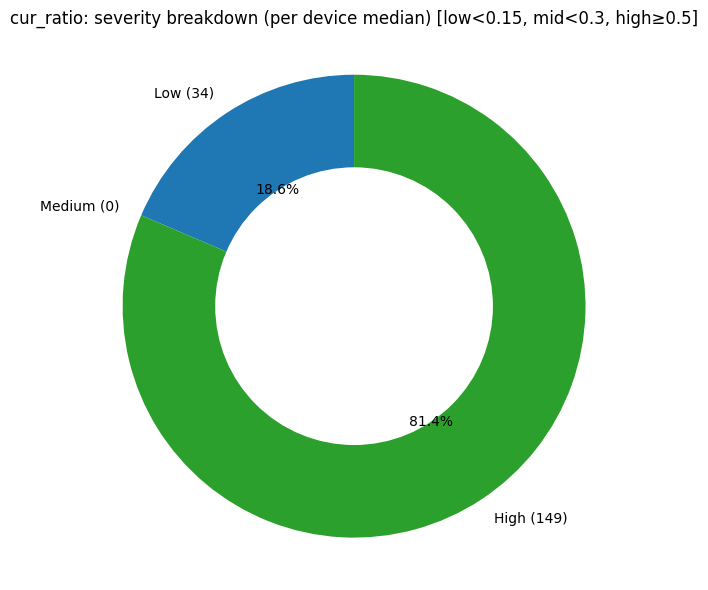

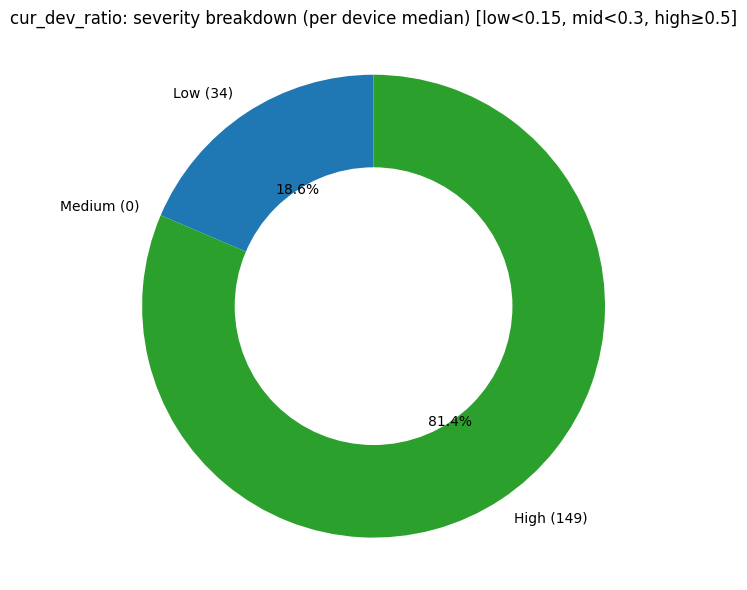

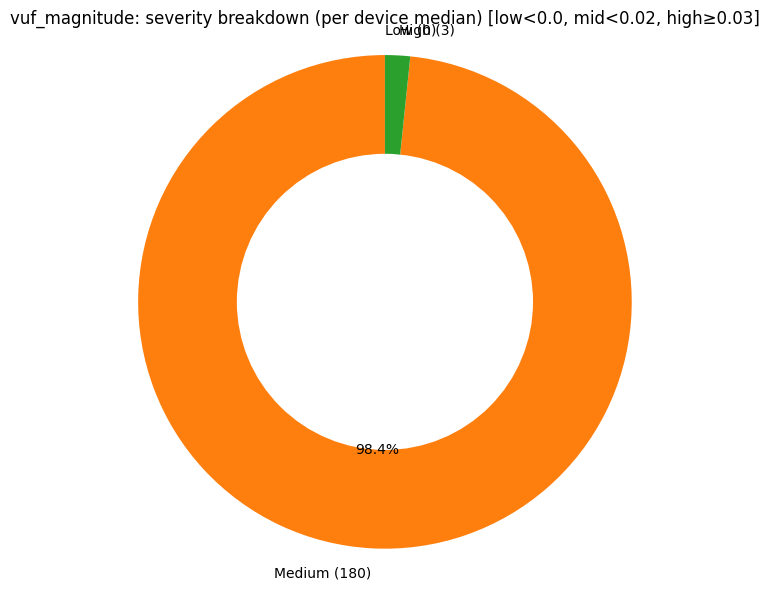

In [59]:
fig = _severity_donut_for_metric(avg_df, "cur_ratio", threshold=0, outdir=".", per_device=True, agg="median", low=low, mid=mid, high=high)
  # in Jupyter this will display; otherwise do: plt.show()
fig = _severity_donut_for_metric(avg_df, "cur_dev_ratio", threshold=0, outdir=".", per_device=True, agg="median", low=low, mid=mid, high=high)
fig = _severity_donut_for_metric(avg_df, "vuf_magnitude", threshold=0, outdir=".", per_device=True, agg="median", low=0, mid=0.02, high=0.03)


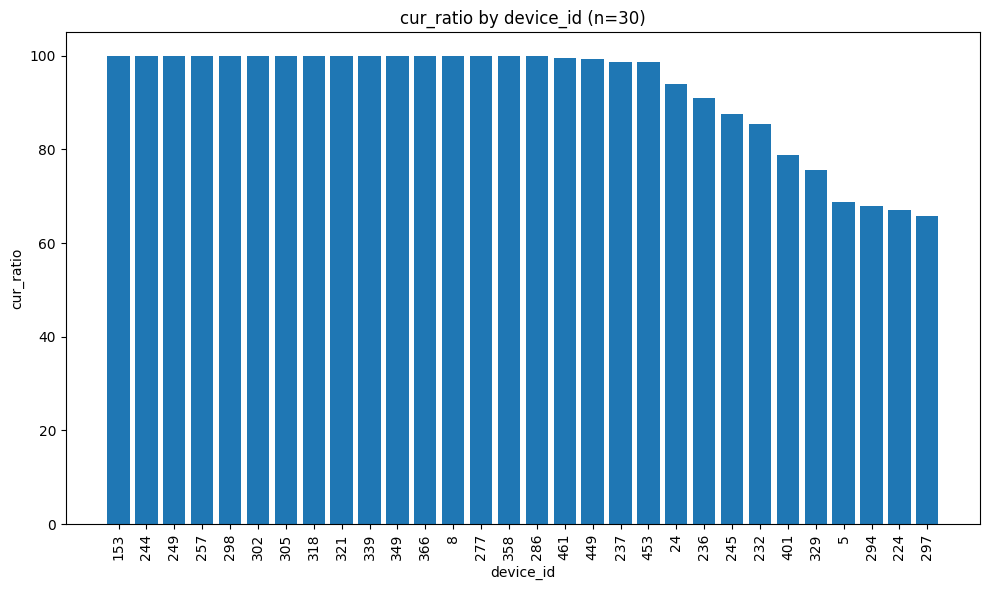

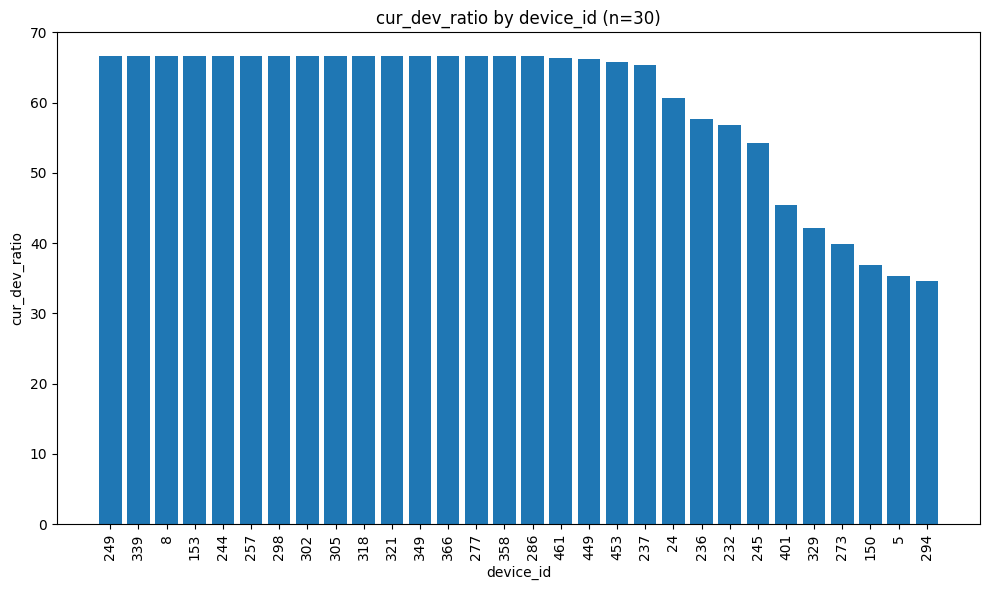

In [60]:
fig = barplot_by_device(avg_df, "cur_ratio", outdir=".", top_n=30)  # outdir ignored
fig = barplot_by_device(avg_df, "cur_dev_ratio", outdir=".", top_n=30) 

Now single device

KeyError: 'imbalance'

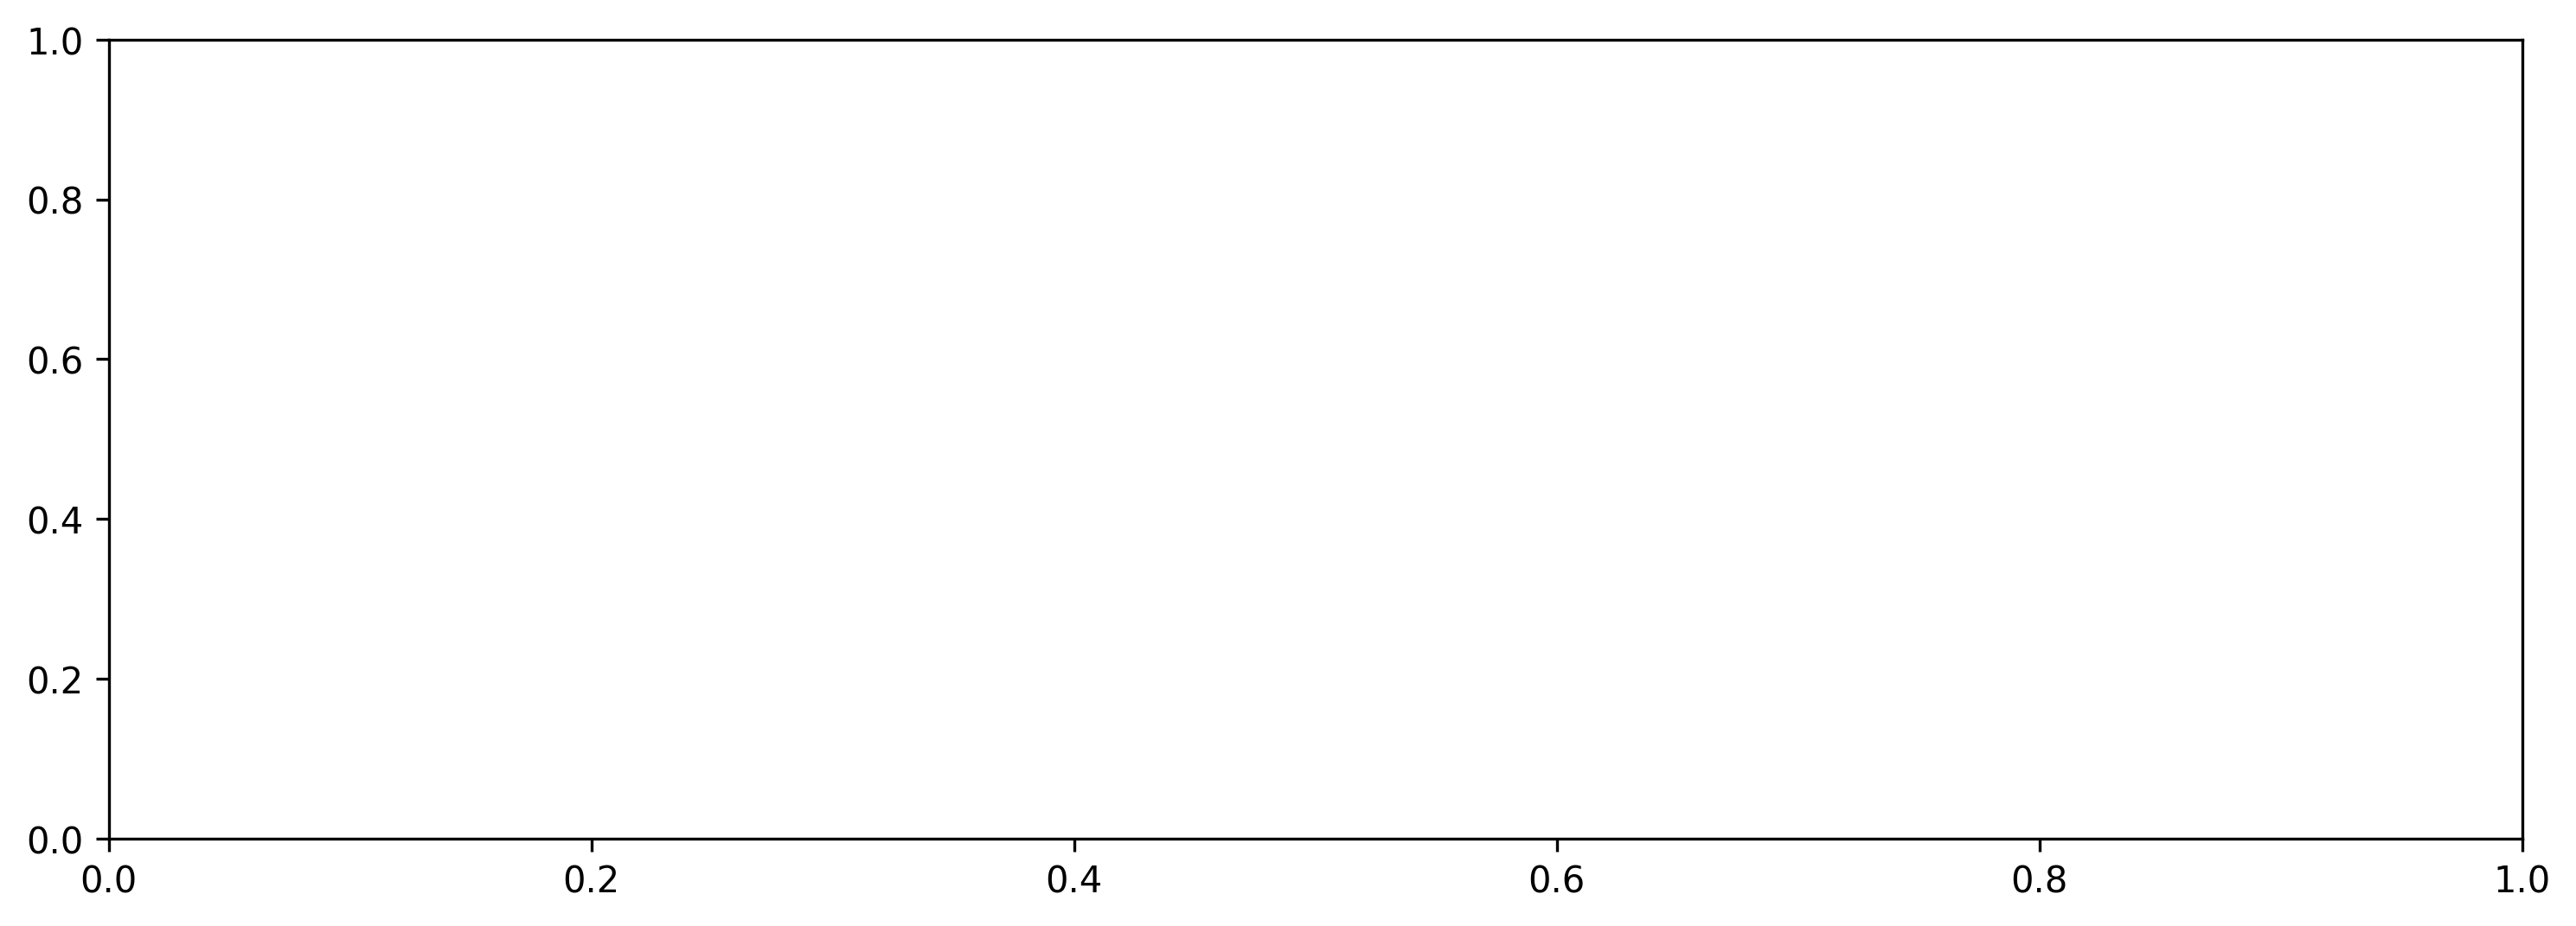

In [ ]:
thresholds = {"mild": low, "moderate": mid, "severe": high}
jrd.plot_colored_cur(df_jn, thresholds, 273, "cur_ratio", "start", "end", 300, "") # need to adjust the code because this expects the metric name to be "imbalance" and "culprit pairs" to be a colunm.
